# DeepSeek-VL2-Tiny on FineSightBench (HF Hub)

Evaluate **deepseek-ai/deepseek-vl2-tiny** on the `Volavion/FineSightBench` dataset (downloaded from the Hugging Face Hub).

**Pipeline**
1. Load dataset from HF Hub (cached under `~/.cache/huggingface/datasets/`).
2. Download / cache the model from HF Hub (no local paths).
3. Run accuracy benchmark on a subset of samples.
4. Visualize per-token last-layer attention on one sample, saving a GIF.


In [8]:
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import torch
from PIL import Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, HTML, display

import finesightbench as _fb
REPO_ROOT = Path(_fb.__file__).resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT))
from finesightbench.evaluation.framework import overlay_attention

MODEL_NAME    = "deepseek-vl2-tiny"
HF_DATASET_ID = "Volavion/FineSightBench"
OUTPUT_DIR    = REPO_ROOT / "outputs" / "vlm_eval_hf" / MODEL_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU   : NVIDIA RTX A6000
Output: /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval_hf/deepseek-vl2-tiny


In [2]:
# ── 1. Download / load the dataset from Hugging Face Hub ─────────────────────
from datasets import load_dataset

print(f"Loading dataset: {HF_DATASET_ID}")
ds = load_dataset(HF_DATASET_ID)   # caches under ~/.cache/huggingface/datasets
print(ds)

print("\nPerception sample 0:")
s0 = ds["perception"][0]
print(f"  image_id  : {s0['image_id']}")
print(f"  task_type : {s0['task_type']}")
print(f"  difficulty: {s0['difficulty']}")
print(f"  question  : {s0['question'][:100]}...")
print(f"  answer    : {s0['answer']}")

Loading dataset: Volavion/FineSightBench
DatasetDict({
    perception: Dataset({
        features: ['image', 'image_id', 'task_type', 'question', 'answer', 'difficulty', 'metadata'],
        num_rows: 3500
    })
    reasoning: Dataset({
        features: ['image', 'image_id', 'task_type', 'question', 'answer', 'difficulty', 'metadata'],
        num_rows: 2520
    })
})

Perception sample 0:
  image_id  : perception_letter_4px_00000
  task_type : letter_recognition
  difficulty: extreme
  question  : What letter is displayed in the image? Answer in JSON format only: {"letter": "<X>"} where <X> is on...
  answer    : {"letter": "A"}


In [ ]:
# ── 2. Download / load model + processor from HF Hub ────────────────────────
# DeepSeek-VL2's pip package targets transformers 4.x. We monkey-patch missing
# symbols, wrap `LlamaAttention.forward` to accept the legacy signature, and
# manually load the checkpoint (transformers 5's custom-code loader silently
# skips weights for this model).
import torch

import transformers.utils.import_utils as _iu
import transformers.pytorch_utils     as _pu
import transformers.models.llama.modeling_llama as _llama
if not hasattr(_iu, "is_torch_fx_available"):
    _iu.is_torch_fx_available = lambda: False
if not hasattr(_pu, "is_torch_greater_or_equal_than_1_13"):
    _pu.is_torch_greater_or_equal_than_1_13 = True
if not hasattr(_llama, "LlamaFlashAttention2"):
    _llama.LlamaFlashAttention2 = _llama.LlamaAttention

from transformers.cache_utils import DynamicCache as _DynCache
if not hasattr(_DynCache, "seen_tokens"):
    _DynCache.seen_tokens = property(
        lambda self: self.get_seq_length() if hasattr(self, "get_seq_length") else 0
    )
if not hasattr(_DynCache, "get_max_length"):
    _DynCache.get_max_length = lambda self: None
if not hasattr(_DynCache, "get_usable_length"):
    _DynCache.get_usable_length = lambda self, new_seq_length, layer_idx=0: (
        self.get_seq_length(layer_idx) if hasattr(self, "get_seq_length") else 0
    )
if not hasattr(_DynCache, "from_legacy_cache"):
    _DynCache.from_legacy_cache = classmethod(lambda cls, past: cls())

# ── Wrap transformers-5 LlamaAttention.forward so deepseek_vl2 can call it
# with the transformers-4 signature (position_ids + 3-tuple return).
from transformers.models.llama.modeling_llama import (
    LlamaAttention as _LlamaAttn, LlamaRotaryEmbedding as _LlamaRoPE,
)
_orig_llama_fwd = _LlamaAttn.forward

def _patched_llama_forward(
    self, hidden_states, position_embeddings=None, attention_mask=None,
    past_key_values=None, position_ids=None, past_key_value=None,
    output_attentions=False, use_cache=False, cache_position=None, **kwargs,
):
    if position_embeddings is None:
        if not hasattr(self, "_fs_rope"):
            self._fs_rope = _LlamaRoPE(self.config).to(hidden_states.device)
        if position_ids is None:
            B, L = hidden_states.shape[:2]
            position_ids = torch.arange(L, device=hidden_states.device).unsqueeze(0).expand(B, -1)
        cos, sin = self._fs_rope(hidden_states, position_ids)
        position_embeddings = (cos, sin)
    # drop the unsupported kwargs
    result = _orig_llama_fwd(
        self, hidden_states,
        position_embeddings=position_embeddings,
        attention_mask=attention_mask,
        past_key_values=past_key_values if past_key_values is not None else past_key_value,
    )
    out, attn_w = result[0], result[1] if len(result) > 1 else None
    return out, attn_w, past_key_value

_LlamaAttn.forward = _patched_llama_forward

from transformers import GenerationMixin
from deepseek_vl2.models import DeepseekVLV2ForCausalLM, DeepseekVLV2Processor
from deepseek_vl2.models.modeling_deepseek import DeepseekV2ForCausalLM

DeepseekVLV2ForCausalLM.all_tied_weights_keys = {}
DeepseekV2ForCausalLM.all_tied_weights_keys   = {}
for _cls in (DeepseekV2ForCausalLM, DeepseekVLV2ForCausalLM):
    if GenerationMixin not in _cls.__mro__:
        _cls.__bases__ = (GenerationMixin,) + _cls.__bases__

MODEL_ID = "deepseek-ai/deepseek-vl2-tiny"
print(f"Loading processor: {MODEL_ID}")
vl_processor = DeepseekVLV2Processor.from_pretrained(MODEL_ID)
tokenizer    = vl_processor.tokenizer

print(f"Loading model (eager attention, bfloat16) ...")
model = DeepseekVLV2ForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map=DEVICE,
    trust_remote_code=True,
    attn_implementation="eager",
)

# transformers 5 silently skips weight loading for this custom model → reload
from safetensors.torch import load_file
from huggingface_hub import snapshot_download
_snap = snapshot_download(MODEL_ID, allow_patterns=["*.safetensors", "*.json"])
import glob as _glob, os as _os
_shards = sorted(_glob.glob(_os.path.join(_snap, "model*.safetensors")))
print(f"Reloading weights from {len(_shards)} shard(s) ...")
_state = {}
for _s in _shards:
    _state.update(load_file(_s))
_missing, _unexpected = model.load_state_dict(_state, strict=False)
print(f"  missing={len(_missing)} unexpected={len(_unexpected)}")
model.to(dtype=torch.bfloat16)
model.eval()
print(f"Model class : {type(model).__name__}")
print(f"Params      : {sum(p.numel() for p in model.parameters()) / 1e9:.2f} B")

MAX_PER_SPLIT = 40
SEED          = 42
import random
rng = random.Random(SEED)
def sample_split(hf_split, n):
    idxs = list(range(len(hf_split)))
    rng.shuffle(idxs)
    return [hf_split[i] for i in idxs[:n]]
subset = {
    "perception": sample_split(ds["perception"], MAX_PER_SPLIT),
    "reasoning" : sample_split(ds["reasoning"],  MAX_PER_SPLIT),
}
print(f"\nSelected: perception={len(subset['perception'])}, reasoning={len(subset['reasoning'])}")

Python version is above 3.10, patching the collections module.
Loading processor: deepseek-ai/deepseek-vl2-tiny
Add pad token = ['<｜▁pad▁｜>'] to the tokenizer
<｜▁pad▁｜>:2
Add image token = ['<image>'] to the tokenizer
<image>:128815
Add grounding-related tokens = ['<|ref|>', '<|/ref|>', '<|det|>', '<|/det|>', '<|grounding|>'] to the tokenizer with input_ids
<|ref|>:128816
<|/ref|>:128817
<|det|>:128818
<|/det|>:128819
<|grounding|>:128820
Add chat tokens = ['<|User|>', '<|Assistant|>'] to the tokenizer with input_ids
<|User|>:128821
<|Assistant|>:128822

Loading model (eager attention, bfloat16) ...


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 26837.41it/s]


Reloading weights from 1 shard(s) ...
  missing=0 unexpected=0
Model class : DeepseekVLV2ForCausalLM
Params      : 3.37 B

Selected: perception=40, reasoning=40


In [12]:
# ── 3. DeepSeek-VL2 inference helpers ────────────────────────────────────────
# `transformers 5` broke `.generate(inputs_embeds=...)` for the pip version of
# deepseek_vl2 (empty `input_ids` reach the decoder). We do manual greedy
# decoding with forward passes over inputs_embeds directly.
def _build_deepseek_inputs(image: Image.Image, question: str):
    conversation = [
        {"role": "<|User|>", "content": f"<image>\n{question}", "images": [image]},
        {"role": "<|Assistant|>", "content": ""},
    ]
    prepare = vl_processor(
        conversations=conversation,
        images=[image],
        force_batchify=True,
        system_prompt="",
    )
    return prepare.to(DEVICE, dtype=torch.bfloat16)


@torch.no_grad()
def deepseek_predict(image: Image.Image, question: str, max_new_tokens: int = 32) -> str:
    prepare       = _build_deepseek_inputs(image, question)
    inputs_embeds = model.prepare_inputs_embeds(**prepare)
    attn_mask     = prepare.attention_mask
    embed_layer   = model.language.get_input_embeddings()
    eos_id        = tokenizer.eos_token_id

    generated: list[int] = []
    cur_embeds, cur_mask = inputs_embeds, attn_mask
    for _ in range(max_new_tokens):
        out = model.language.model(
            inputs_embeds=cur_embeds, attention_mask=cur_mask,
            use_cache=False, return_dict=True,
        )
        logits  = model.language.lm_head(out.last_hidden_state[:, -1, :])
        next_id = int(logits.argmax(dim=-1).item())
        if next_id == eos_id:
            break
        generated.append(next_id)
        next_emb = embed_layer(torch.tensor([[next_id]], device=DEVICE)).to(cur_embeds.dtype)
        cur_embeds = torch.cat([cur_embeds, next_emb], dim=1)
        cur_mask   = torch.cat(
            [cur_mask, torch.ones((1, 1), dtype=cur_mask.dtype, device=DEVICE)], dim=1,
        )
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


# ── 4. Run accuracy benchmark on the subset ──────────────────────────────────
import time, re as _re
from collections import defaultdict

def _norm(s):
    return _re.sub(r"\s+", " ", str(s).strip().lower())

def exact_match(pred, gold):
    p, g = _norm(pred), _norm(gold)
    return int(p == g or g in p)

records  = []
by_split = defaultdict(lambda: [0, 0])
t0       = time.time()
for split in ("perception", "reasoning"):
    for i, s in enumerate(subset[split]):
        img = s["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))
        img = img.convert("RGB")
        try:
            pred = deepseek_predict(img, s["question"])
        except Exception as e:
            pred = f"<error: {type(e).__name__}: {e}>"
        ok = exact_match(pred, s["answer"])
        by_split[split][0] += ok
        by_split[split][1] += 1
        records.append({
            "split": split, "image_id": s["image_id"], "task": s["task_type"],
            "gold": s["answer"], "pred": pred, "correct": bool(ok),
        })
        if (i + 1) % 10 == 0:
            print(f"  [{split}] {i+1}/{len(subset[split])} — acc so far: "
                  f"{by_split[split][0]}/{by_split[split][1]}")

elapsed = time.time() - t0
print(f"\nElapsed: {elapsed:.1f}s")

print("=== Accuracy ===")
oc = ot = 0
summary = {}
for split, (c, t) in by_split.items():
    print(f"  {split:<11s}: {c}/{t} = {c/t:.3%}")
    summary[split] = {"correct": c, "total": t, "accuracy": c / t}
    oc += c; ot += t
print(f"  {'overall':<11s}: {oc}/{ot} = {oc/ot:.3%}")
summary["overall"] = {"correct": oc, "total": ot, "accuracy": oc / ot}

(OUTPUT_DIR / "predictions.jsonl").write_text(
    "\n".join(json.dumps(r, ensure_ascii=False) for r in records)
)
(OUTPUT_DIR / "report.json").write_text(
    json.dumps({
        "model"   : MODEL_NAME,
        "dataset" : HF_DATASET_ID,
        "subset"  : {"perception": MAX_PER_SPLIT, "reasoning": MAX_PER_SPLIT},
        "seed"    : SEED,
        "elapsed_seconds": elapsed,
        "results" : summary,
    }, indent=2)
)
print(f"\nPredictions → {OUTPUT_DIR/'predictions.jsonl'}")
print(f"Report      → {OUTPUT_DIR/'report.json'}")

  [perception] 10/40 — acc so far: 8/10
  [perception] 20/40 — acc so far: 17/20
  [perception] 30/40 — acc so far: 25/30
  [perception] 40/40 — acc so far: 30/40
  [reasoning] 10/40 — acc so far: 0/10
  [reasoning] 20/40 — acc so far: 1/20
  [reasoning] 30/40 — acc so far: 1/30
  [reasoning] 40/40 — acc so far: 1/40

Elapsed: 172.7s
=== Accuracy ===
  perception : 30/40 = 75.000%
  reasoning  : 1/40 = 2.500%
  overall    : 31/80 = 38.750%

Predictions → /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval_hf/deepseek-vl2-tiny/predictions.jsonl
Report      → /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval_hf/deepseek-vl2-tiny/report.json


In [ ]:
# ── 5. Last-layer attention visualization ─────────────────────────────────────
##
## DeepSeek-VL2 does not expose visual tokens through standard `<vision_start>`
## boundaries — instead it injects patch embeddings at positions marked by
## `images_seq_mask`. We use that mask to locate visual token positions and
## directly read the last-layer attention maps.

@torch.no_grad()
def deepseek_predict_with_attention(image, question, max_new_tokens: int = 20):
    prepare         = _build_deepseek_inputs(image, question)
    inputs_embeds   = model.prepare_inputs_embeds(**prepare)
    attention_mask  = prepare.attention_mask
    images_seq_mask = prepare.images_seq_mask[0].cpu().numpy()   # (Lp,)
    input_len       = inputs_embeds.shape[1]
    embed_layer     = model.language.get_input_embeddings()
    eos_id          = tokenizer.eos_token_id

    # 1. Manual greedy decoding (collecting token ids)
    generated = []
    cur_embeds, cur_mask = inputs_embeds, attention_mask
    for _ in range(max_new_tokens):
        out = model.language.model(
            inputs_embeds=cur_embeds, attention_mask=cur_mask,
            use_cache=False, return_dict=True,
        )
        logits = model.language.lm_head(out.last_hidden_state[:, -1, :])
        nid    = int(logits.argmax(dim=-1).item())
        if nid == eos_id:
            break
        generated.append(nid)
        ne = embed_layer(torch.tensor([[nid]], device=DEVICE)).to(cur_embeds.dtype)
        cur_embeds = torch.cat([cur_embeds, ne], dim=1)
        cur_mask   = torch.cat([cur_mask, torch.ones((1, 1), device=DEVICE, dtype=cur_mask.dtype)], dim=1)

    answer = tokenizer.decode(generated, skip_special_tokens=True).strip()
    tokens = [tokenizer.decode([t], skip_special_tokens=False) for t in generated]
    num_gen = len(generated)
    if num_gen == 0:
        raise RuntimeError("Model generated zero tokens — cannot visualize attention.")

    # 2. Full forward pass with attentions on the concatenated sequence
    fwd = model.language.model(
        inputs_embeds=cur_embeds, attention_mask=cur_mask,
        output_attentions=True, use_cache=False, return_dict=True,
    )
    # Each layer: (1, H, T, T)
    all_attns = np.stack([a.squeeze(0).float().cpu().numpy() for a in fwd.attentions], axis=0)
    print(f"Attention tensor: {all_attns.shape}  (layers, heads, seq, seq)")

    # 3. Visual token indices on the ORIGINAL prompt (before generated tokens)
    vis_idx = np.where(images_seq_mask)[0]
    num_vis = len(vis_idx)
    side    = int(num_vis ** 0.5)
    grid_h  = side
    grid_w  = side
    num_keep = grid_h * grid_w
    print(f"Visual tokens: {num_vis}  →  grid {grid_h}×{grid_w} (remainder {num_vis - num_keep} ignored)")

    # 4. Directly use last-layer mean-across-heads attention for each generated token
    last_attn = all_attns[-1].mean(axis=0)      # (T, T)
    keep_idx  = vis_idx[:num_keep]
    heatmaps  = []
    for i in range(num_gen):
        q_pos = input_len + i
        vec   = last_attn[q_pos, keep_idx].astype(np.float64)
        vmin, vmax = float(vec.min()), float(vec.max())
        vec   = (vec - vmin) / (vmax - vmin + 1e-9)
        heatmaps.append(vec.reshape(grid_h, grid_w))

    return {
        "answer": answer, "tokens": tokens, "heatmaps": heatmaps,
        "grid": (grid_h, grid_w),
        "attention_shape": all_attns.shape,
    }


# Pick one reasoning sample for last-layer attention viz
ATTN_SAMPLE_IDX = 0
sample = subset["reasoning"][ATTN_SAMPLE_IDX]
image  = sample["image"]
if not isinstance(image, Image.Image):
    image = Image.fromarray(np.asarray(image))
image = image.convert("RGB")
question = sample["question"]

print(f"Attention sample : {sample['image_id']}")
print(f"Task             : {sample['task_type']}")
print(f"Question         : {question[:120]}...")
print(f"Gold answer      : {sample['answer']}\n")

attn_result = deepseek_predict_with_attention(image, question, max_new_tokens=20)
print(f"\nModel answer    : {attn_result['answer']!r}")
print(f"Tokens ({len(attn_result['tokens'])}): {attn_result['tokens']}")

Attention sample : reasoning_counting_chain_32px_n20_01838
Task             : counting_chain
Question         : The image contains different animals. Count the number of each type of animal and provide the total. Answer in JSON form...
Gold answer      : {"counts": {"bird": 6, "dog": 7, "cat": 5, "rabbit": 2}, "total": 20}

Attention tensor: (12, 10, 1124, 1124)  (layers, heads, seq, seq)
Visual tokens: 1023  →  grid 31×31 (remainder 62 ignored)

Model answer    : '{"counts": {"bird": 5, "dog": 4, "cat":'
Tokens (20): ['{"', 'count', 's', '":', ' {"', 'bird', '":', ' ', '5', ',', ' "', 'dog', '":', ' ', '4', ',', ' "', 'cat', '":', ' ']


Saved GIF (257.8 KB) → /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval_hf/deepseek-vl2-tiny/reasoning_counting_chain_32px_n20_01838_attention.gif



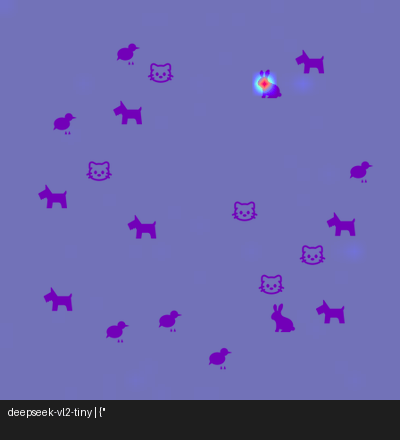

In [10]:
import io, base64
from PIL import ImageDraw as PILImageDraw

def make_attention_gif_bytes(
    image, tokens, heatmaps,
    frame_size=(400, 400), caption_height=40, fps=3,
    alpha=0.55, colormap="jet", label="",
):
    duration_ms = int(1000 / fps)
    W, H   = frame_size
    totalH = H + caption_height
    frames = []
    cumulative = ""
    for tok_str, hmap in zip(tokens, heatmaps):
        blended = overlay_attention(
            image.resize((W, H), Image.LANCZOS),
            hmap, alpha=alpha, colormap=colormap,
        )
        frame = Image.new("RGB", (W, totalH), color=(30, 30, 30))
        frame.paste(blended, (0, 0))
        draw = PILImageDraw.Draw(frame)
        cumulative += tok_str
        caption = f"{label} | {cumulative.strip()}" if label else cumulative.strip()
        draw.text((8, H + 6), caption[:80], fill=(255, 255, 255))
        frames.append(frame)
    buf = io.BytesIO()
    frames[0].save(
        buf, format="GIF", save_all=True, append_images=frames[1:],
        loop=0, duration=duration_ms, optimize=False,
    )
    buf.seek(0)
    return buf.read()

gif_path = OUTPUT_DIR / f"{sample['image_id']}_attention.gif"
gif_bytes = make_attention_gif_bytes(
    image=image,
    tokens=attn_result["tokens"],
    heatmaps=attn_result["heatmaps"],
    label=MODEL_NAME,
)
gif_path.write_bytes(gif_bytes)
print(f"Saved GIF ({len(gif_bytes)/1024:.1f} KB) → {gif_path}")

b64 = base64.b64encode(gif_bytes).decode("utf-8")
display(HTML(f'<img src="data:image/gif;base64,{b64}" width="450">'))

In [11]:
# ── 5. Static grid of all per-token heatmaps ────────────────────────────────
tokens   = attn_result["tokens"]
heatmaps = attn_result["heatmaps"]
n        = len(tokens)

fig, axes = plt.subplots(1, n, figsize=(3 * n, 4.5))
if n == 1:
    axes = [axes]

img_rgb = np.array(image)
for i, (tok, hmap) in enumerate(zip(tokens, heatmaps)):
    ax  = axes[i]
    hup = np.array(
        Image.fromarray((hmap * 255).astype(np.uint8)).resize(image.size, Image.BILINEAR)
    ) / 255.0
    ax.imshow(img_rgb)
    ax.imshow(hup, cmap="jet", alpha=0.5, vmin=0, vmax=1)
    ax.set_title(repr(tok), fontsize=8, pad=4)
    ax.axis("off")

fig.suptitle(
    f"{MODEL_NAME}  —  {sample['image_id']}\n"
    f"Q: {question[:100]}...\n"
    f"Answer: {attn_result['answer']}  (GT: {sample['answer']})",
    fontsize=9, y=1.02,
)
plt.tight_layout()
grid_png = OUTPUT_DIR / f"{sample['image_id']}_attention_grid.png"
plt.savefig(grid_png, dpi=110, bbox_inches="tight")
plt.show()
print(f"Saved grid → {grid_png}")

Saved grid → /home/snt/projects_lujun/FineSightBench/outputs/vlm_eval_hf/deepseek-vl2-tiny/reasoning_counting_chain_32px_n20_01838_attention_grid.png
